## Глава 13: Углубленное знакомство с PyTorch 

In [1]:
from IPython.display import Image
%matplotlib inline

В этой главе для реализации нейронной сети мы будем использовать различные возможности API PyTorch. В частности, мы снова обратимся к возможностям модуля torch.nn, предоставляющего несколько уровней абстракции, что делает реализацию стандартных архитектур очень простой и удобной. Этот модуль также позволяет нам создавать пользовательские слои нейросети, что очень полезно в исследовательских проектах, требующих дополнительной настройки. Позже в этой главе мы организуем такой пользовательский слой.

Чтобы проиллюстрировать различные способы построения модели с помощью модуля torch.nn, мы рассмотрим классическую задачу исключающего ИЛИ (XOR). Сначала мы будем строить многослойные персептроны, используя класс sequential. Затем перейдем и к другим методам - таким как создание подкласса nn.Module для определения пользовательских слоев. Наконец, мы поработаем над двумя реальными проектами, которые охватьmают этапы машинного обучения от ввода данных до прогнозирования.

Таким образом, в этой главе мы рассмотрим следующие темы:\
♦ работу с графами вычислений в PyTorch;\
♦ работу с тензорными объектами PyTorch;\
♦ решение классической задачи XOR и понятие емкости модели;\
♦ построение сложных нейросетевых моделей с использованием классов PyTorch Sequential И nn.Module;\
♦ вычисление градиентов с использованием автоматического дифференцирования и torch.autograd. 

### 13.1. Основные возможности PyTorch 

Как было сказано в предыдущей главе, PyTorch предоставляет нам масштабируемый многоплатформенный программный интерфейс для реализации и запуска алгоритмов машинного обучения. После первого выпуска в 2016 г. и выхода версии 1.0 в 2018 г. PyTorch стал одним из двух самых популярных фреймворков для глубокого обучения. В библиотеке PyTorch применяются динамические графы вычислений, преимущество которых заключается в том, что они более гибкие по сравнению с их статическими аналогами. Динамические графы вычислений удобны для отладки - PyTorch позволяет чередовать этапы объявления графа и его оценки. Вы можете выполнять код построчно, имея при этом полный доступ ко всем переменным. Это очень важная особенность, которая делает разработку и обучение нейронной сети очень удобными.

PyTorch - полностью бесплатная библиотека с открытым исходным кодом. В ее разработке принимает участие большая команда инженеров-программистов, которые постоянно расширяют и улучшают эту библиотеку. Благодаря открытому исходному коду она также пользуется мощной поддержкой со стороны сообщества заинтересованных сторонних разработчиков, которые активно вносят в нее свой посильный вклад. Это сделало библиотеку PyTorch полезной как для академических исследователей, так и для разработчиков производственных решений. Еще одним следствием указанных обстоятельств стало наличие обширной документации и учебных пособий, которые помогают новым пользователям PyTorch.

Важной ключевой особенностью PyTorch, которая также была отмечена в предыдущей главе, является ее способность работать с одним или несколькими графическими процессорами (GPU). Это позволяет пользователям очень эффективно обучать модели глубокого обучения на больших наборах данных в крупномасштабных системах. И последнее, но не менее важное - PyTorch поддерживает мобильное развертывание, что также делает ее очень подходящим инструментом для производства. В следующем разделе мы рассмотрим, как тензоры и функции в PyTorch связаны между собой посредством графа вычислений. 

### 13.2. Граф вычислений PyTorch 

PyTorch выполняет свои вычисления с использованием направленного ациклического графа (Directed Acyclic Graph, DAG). В этом разделе вы узнаете, как определяют графы для простых арифметических вычислений. Затем мы рассмотрим парадигму динамического графа, а также создание графов на лету в PyTorch. 

#### 13.2.1. Вкратце о графе вычислений 

Вся работа PyTorch основана на построении графа вычислений, который служит для получения взаимосвязей между тензорами от входа до выхода. Допустим, у нас есть тензоры ранга 0 (скаляры) а, Ь и с, и мы хотим найти z = 2 х (а-Ь) + с. 

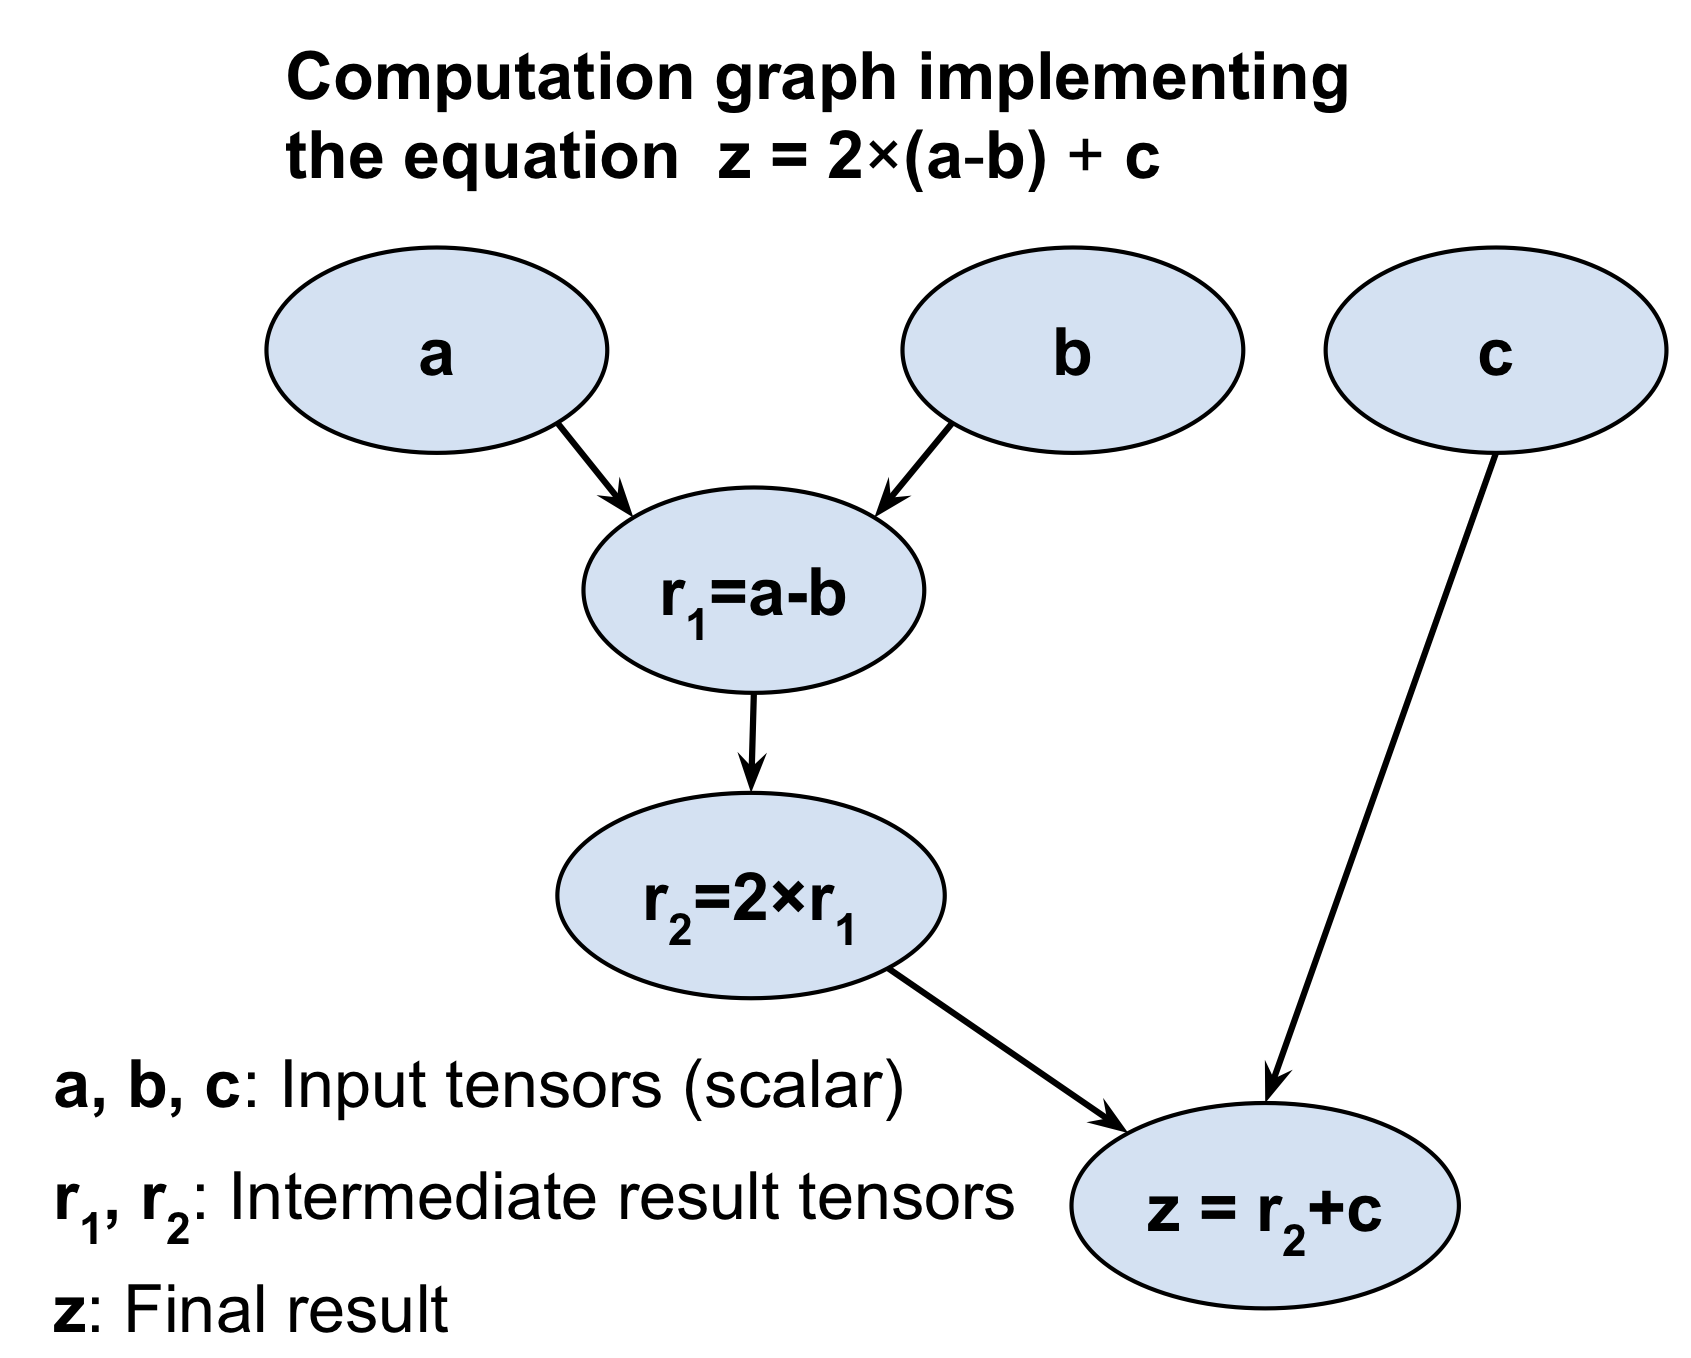

In [2]:
Image(filename='figures/13_01.png', width=400)

Как видите, граф вычислений - это просто сеть узлов. Каждый узел похож на операцию, которая применяет функцию к своему входному тензору или тензорам и возвращает ноль или более тензоров в качестве выходных данных. PyTorch строит этот граф вычислений и использует его для соответствующего вычисления градиентов. В следующем разделе вы увидите несколько примеров создания графа вычислений с использованием PyTorch. 

### 13.2.2. Создание графа в PyTorch 

Давайте рассмотрим простой пример, иллюстрирующий создание графа в PyTorch для вычисления z = 2 х (а - Ь) + с, как показано на рис. 13.1. Переменные а, Ь и с - это скаляры (одиночные числа), и мы определяем их как тензоры PyTorch. Для создания графа достаточно определить обычную функцию Python с а, Ь и с в качестве входных аргументов.

Чтобы выполнить вычисление, нужно вызвать эту функцию с тензорными объектами в качестве аргументов. Заметим, что такие функции PyTorch, как add (сложение), sub (или suЬstract, вычитание) и mul (или multiply, умножение), также позволяют нам предоставлять входные данные более высокого ранга в форме тензорного объекта PyTorch. В следующем примере кода мы предоставляем скалярные входные данные (ранг 0), а также входные данные ранга 1 и ранга 2 в виде списков: 

In [3]:
import torch
def compute_z(a, b, c):
    r1 = torch.sub(a, b)
    r2 = torch.mul(r1, 2)
    z = torch.add(r2, c)
    return z

print('Scalar Inputs:', compute_z(torch.tensor(1), torch.tensor(2), torch.tensor(3)))
print('Rank 1 Inputs:', compute_z(torch.tensor([1]), torch.tensor([2]), torch.tensor([3])))
print('Rank 2 Inputs:', compute_z(torch.tensor([[1]]), torch.tensor([[2]]), torch.tensor([[3]])))

Scalar Inputs: tensor(1)
Rank 1 Inputs: tensor([1])
Rank 2 Inputs: tensor([[1]])


### 13.3. Тензорные объекты PyTorch для хранения и обновления параметров модели 

Вы уже встречали тензорные объекты в главе 12. В PyTorch специальный тензорный объект, для которого нужно вычислять градиенты, позволяет нам хранить и обновлять параметры наших моделей во время обучения. Такой тензор можно создать, просто присвоив параметру requires_grad значение тrue для заданных пользователем начальных значений. Заметим, что на момент подготовки книги (середина 2021 г.) только тензоры с плавающей запятой и комплексный тип dtype могли требовать вычисления градиентов. Следующий код генерирует тензорные объекты типа float32: 

In [4]:
a = torch.tensor(3.14, requires_grad=True)
b = torch.tensor([1.0, 2.0, 3.0], requires_grad=True) 
print(a)
print(b)

tensor(3.1400, requires_grad=True)
tensor([1., 2., 3.], requires_grad=True)


Обратите внимание, что по умолчанию для параметра requires _grad задано значение False. Это значение можно установить в True при помощи метода requires_grad _(). 

In [5]:
a.requires_grad

True

In [6]:
w = torch.tensor([1.0, 2.0, 3.0])
print(w.requires_grad)

False


In [7]:
w.requires_grad_()
print(w.requires_grad)

True


Напомним, что нейросетевым моделям инициализация параметров случайными значениями весовых коэффициентов необходима для нарушения симметрии во время обратного распространения: в противном случае многослойная нейросеть была бы не полезнее однослойной - такой как логистическая регрессия. При создании тензора PyTorch тоже можно использовать схему случайной инициализации. PyTorch генерирует случайные числа на основе различных распределений вероятностей. В следующем примере мы рассмотрим некоторые стандартные методы инициализации, которые также доступны в модуле torch.nn.init.
Рассмотрим создание тензора с инициализацией Глорота - классической схемой случайной инициализации, предложенной Ксавьером Глоротом и Йошуа Бенжио. Для этого сначала создадим пустой тензор и оператор с именем init как объект класса GlorotNormal. Затем заполним этот тензор значениями в соответствии с инициализацией Глорота, вызывая метод xavier_normal_(). В следующем примере мы инициализируем тензор формы 2хЗ: 

In [8]:
import torch.nn as nn

torch.manual_seed(1)
w = torch.empty(2, 3)
nn.init.xavier_normal_(w)
print(w)
 

tensor([[ 0.4183,  0.1688,  0.0390],
        [ 0.3930, -0.2858, -0.1051]])


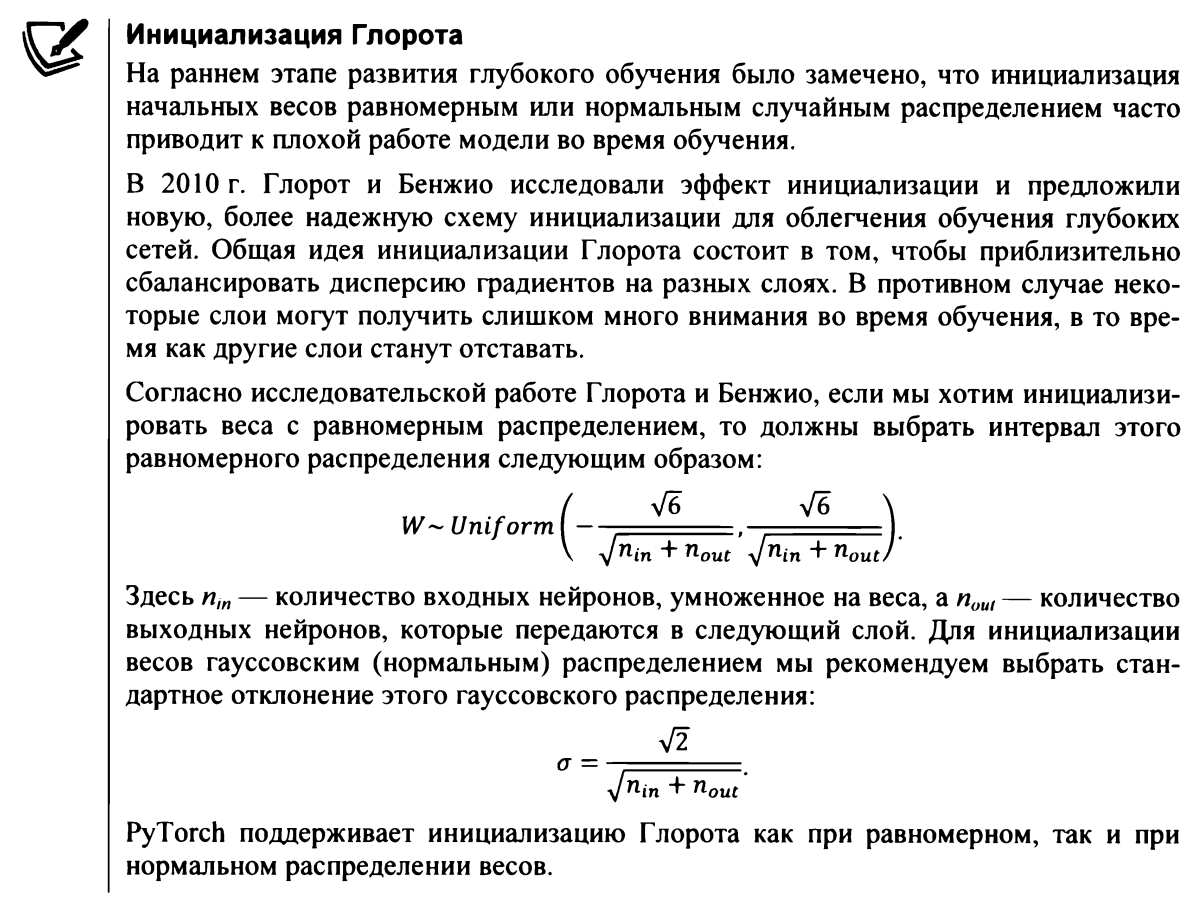

In [9]:
Image(filename='figures/Глорот.png', width=500)

Теперь в качестве более близкого к практике варианта применения определим два объекта тensor внутри базового класса nn.мoctule: 

In [10]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.w1 = torch.empty(2, 3, requires_grad=True)
        nn.init.xavier_normal_(self.w1)
        self.w2 = torch.empty(1, 2, requires_grad=True)
        nn.init.xavier_normal_(self.w2)

Затем эти два тензора можно использовать в качестве весов, градиенты которых будут вычисляться с помощью автоматического дифференцирования. 

### 13.4. Вычисление градиентов с помощью автоматического дифференцирования 

Как вы уже знаете, оптимизация нейронной сети требует вычисления градиентов потерь по отношению к ее весам. Это необходимо для алгоритмов оптимизации - таких как стохастический градиентный спуск (SGD). Кроме того, у градиентов есть и другие применения - такие как диагностика сети, помогающие выяснить, почему модель дает определенный прогноз для тестового примера. Поэтому имеет смысл более детально рассмотреть вычисление градиента. 

#### 13.4.1. Вычисление градиентов потерь по обучаемым переменным 

PyTorch поддерживает автоматическое дифференцирование, которое можно рассматривать как реализацию цепного правила для вычисления градиентов вложенных функций. Далее для простоты мы будем использовать термин «градиент» для обозначения как частных производных, так и градиентов. 

Частную производную $\partial f$ можно рассматривать как скорость изменения многомерной функции - т. е. функции с несколькими входами $f(х_1,x_2, ... )$, по отношению к одному из ее входов (например, $x_1$). Градиент f функции представляет собой вектор, состоящий из всех частных производных входных данных: $f = (\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, ... )$.

Когда мы определяем последовательность операций, которые приводят нас к выходным или даже промежуточным тензорам, PyTorch предоставляет контекст для вычисления градиентов этих тензоров по отношению к их зависимым узлам в графе вычислений. Чтобы вычислить такие градиенты, мы можем вызвать метод backward из модуля torch.autograd. Он рассчитывает сумму градиентов того или иного тензора относительно листовых узлов (конечных узлов) в графе.
Давайте возьмем простой пример, в котором вычислим z = wx + Ь и определим потерю как квадрат потери между целью у и прогнозом z $Loss = (у- z)^2$. В более общем случае, когда у нас есть несколько прогнозов и целей, мы вычисляем потери как сумму квадратов ошибок: $Loss = \sum_{i} (Y_i - z_i)^2$. Чтобы реализовать это вычисление в PyTorch, определим параметры модели w и Ь как переменные (тензоры с атрибутом requires_gradient, установленным в тrue), а входные данные х и у - как тензоры по умолчанию. Мы вычислим тензор потерь и используем его для расчета градиентов параметров модели w
и Ь следующим образом: 

In [11]:
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.5, requires_grad=True) 

x = torch.tensor([1.4])
y = torch.tensor([2.1])

z = torch.add(torch.mul(w, x), b)
 
loss = (y-z).pow(2).sum()
loss.backward()

print('dL/dw: ', w.grad)
print('dL/db: ', b.grad)


dL/dw:  tensor(-0.5600)
dL/db:  tensor(-0.4000)


Вычисление значения z является прямым проходом в нейронной сети. Мы применили метод backward к тензору loss для вычисления $\frac{\partial Loss}{\partial w}$ и $\frac{\partial Loss}{\partial b}$.  Так как это очень простой пример, мы можем получить $\frac{\partial Loss}{\partial w} = 2х (wx + b - у)$ непосредственно из формулы, чтобы убедиться, что вычисленные градиенты соответствуют результатам, полученным в предьщущем примере кода: 

In [12]:
# роверка вычисленного градиента
print(2 * x * ((w * x + b) - y))

tensor([-0.5600], grad_fn=<MulBackward0>)


#### 13.4.2. Как работает автоматическое дифференцирование? 

Автоматическое дифференцирование представляет собой набор вычислительных методов для нахождения градиентов произвольных арифметических операций. Во время этого процесса градиенты (выраженные в виде последовательности операций) получаются путем накопления градиентов за счет повторных применений цепного правила. Чтобы лучше понять принцип автоматического дифференцирования, рассмотрим последовательность вложенных вычислений $у = f(g(h(x)))$ с входом х и выходом у. Эту последовательность можно разбить на несколько шагов:
1. $u_0 =х$.
2. $u_1 = h(x)$.
3. $u_2 = g(u_1)$.
4. $u_3 = f(u_2) = у$.

Производная $\frac{dy}{dx}$ может быть вычислена двумя разными способами:\
прямым накоплением­, которое начинается $\frac{du_3}{du_0} = \frac{du_3}{du_2} \frac{du_2}{du_0}$ , и обратным накоплением, которое начина­ется с $\frac{du_3}{du_0} = \frac{du_3}{du_1} \frac{du_1}{du_0}$ . PyTorch использует обратное накопление, которое лучше подхс­дит для реализации обратного распространения ошибки. 

#### 13.4.3. Состязательные примеры

Вычисление градиентов потерь по отношению ко входному примеру используется для генерации состязательных примеров (или состязательных атак). В компьютерном зрении состязательные примеры - это примеры, которые генерируются путем добавления небольшого незаметного шума (или возмущений) ко входному примеру, что приводит к их неправильной классификации глубокой нейросетью. Рассмотрение состязательных примеров выходит за рамки книги, но если вас интересует эта тема, вы можете прочитать о ней в статье Кристиана Сеrеди. 

### 13.5. Упрощение реализации популярных архитектур с помощью модуля torch.nn 

Вы уже видели несколько примеров построения модели нейронной сети прямого распространения (например, многослойного персептрона) и определения последовательности слоев с помощью класса nn.Module. Прежде чем приступить к подробному изучению nn.Module, давайте кратко рассмотрим другой подход к созданию этих слоев - с помощью nn.Sequential. 

#### 13.5.1. Реализация моделей на основе nn.Sequential

С помощью класса nn.Sequential слои, находящиеся внутри модели, соединяются каскадным образом. В следующем примере мы построим модель с двумя полностью связанными слоями: 

In [13]:
model = nn.Sequential(nn.Linear(4, 16), nn.ReLU(), nn.Linear(16, 32), nn.ReLU())
model

Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
)

Мы указали слои и создали экземпляр model после передачи слоев классу nn. Sequential. Выход первого полносвязного слоя используется как вход для первого слоя ReLU. Выход первого слоя ReLU становится входом для второго полносвязного слоя. Наконец, выход второго полносвязного слоя служит в качестве входа для второго слоя ReLU. Мы можем дополнительно настроить эти слои, например применяя к параметрам различные функции активации, инициализаторы или методы регуляризации. Исчерпывающий и полный список доступных опций для большинства из этих категорий можно
найти в официальной документации:\
♦ выбор функций активации - https://pytorch.org/docs/stahle/nn.html#non-linearactivations-weighted-sum-nonlinearity;\
♦ инициализация параметров слоя через nn.init - https://pytorch.org/docs/stahle/nn.init.html;\
♦ применение регуляризации L2 к параметрам слоя (для предотвращения переобучения) с помощью параметра weight_decay некоторых оптимизаторов в torch.optim https://pytorch.org/docs/stahle/optim.html;\
♦ применение регуляризации L1 к параметрам слоя (для предотвращения переобучения) путем добавления штрафного члена L1 к тензору потерь, что мы реализуем далее.

В следующем примере кода мы настроим первый полносвязный слой, указав начальное распределение значений веса. Затем настроим второй полносвязный слой, вычислив штрафной член L1 для матрицы весов: 

In [14]:
nn.init.xavier_uniform_(model[0].weight)
l1_weight = 0.01
l1_penalty = l1_weight * model[2].weight.abs().sum()


Здесь мы инициализировали вес первого линейного слоя с помощью инициализации Глорота и вычислили норму L1 веса второго линейного слоя. Кроме того, мы также можем указать тип оптимизатора и функцию потерь для обучения. Опять же, полный список всех доступных опций можно найти в официальной
документации:\
♦ оптимизация при помощи torch.optim https://pytorch.org/docs/stahle/optim.html#algorithms;\
♦ функции потерь - https://pytorch.org/docs/stahle/nn.html#loss-functions. 

#### 13.5.2. Выбор функции потерь

В том, что касается выбора алгоритмов оптимизации, наиболее широко используемыми методами являются SGD и Adam. Выбор функции потерь зависит от задачи - например, для задачи регрессии можно использовать среднеквадратичную ошибку. Семейство функций потерь по критерию перекрестной энтропии предназначено для задач классификации, которые подробно обсуждаются в главе 14. Кроме того, вы можете использовать приемы, изученные в предыдущих главах (например, приемы оценки модели из главы 6) в сочетании с соответствующими метриками.
Например, достоверность и полнота, точность, площадь под кривой (AUC), а также ложноотрицательные и ложноположительные оценки - вполне подходящие метрики для оценки моделей классификации. 

В следующем примере мы воспользуемся оптимизатором SGD и потерей перекрестной
энтропии для задачи бинарной классификации: 

In [15]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

Далее мы обратимся к более практическому примеру - решению классической задачи классификации XOR, где для построения модели применим класс nn.Sequential(). Попутно вы также узнаете о способности модели обрабатывать нелинейные разделяющие границы. Затем мы рассмотрим создание модели с помощью nn.Module, что даст нам больше гибкости и контроля над слоями сети. 

#### 13.5.3. Решение задачи классификации XOR 

Задача классификации XOR (исключающего ИЛИ)- это классическая задача для анализа способности модели построить нелинейную разделяющую границу между двумя классами. Сначала мы создадим демонстрационный набор данных из 200 обучающих примеров с двумя признаками $(х_0,x_1)$, взятыми из равномерного распределения в интервале [-1, 1). Затем присвоим метку истинности каждому обучающему примеру i в соответствии со следующим правилом:\
$y^{(i)} = 0$ if $x_0^{(i)} * x_1^{(i)} < 0$, else 1\
Мы воспользуемся половиной данных (100 обучающих примеров) для обучения, а оставшейся половиной - для валидации. Следующий код осуществляет генерацию данных и разделение их на обучающие и проверочные примеры: 

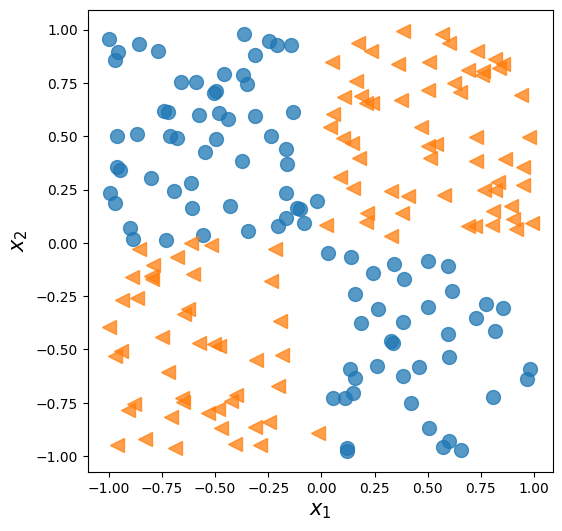

In [16]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(1)
torch.manual_seed(1)
x = np.random.uniform(low=-1, high=1, size=(200, 2))
y = np.ones(len(x))
y[x[:, 0] * x[:, 1]<0] = 0

n_train = 100
x_train = torch.tensor(x[:n_train, :], dtype=torch.float32)
y_train = torch.tensor(y[:n_train], dtype=torch.float32)
x_valid = torch.tensor(x[n_train:, :], dtype=torch.float32)
y_valid = torch.tensor(y[n_train:], dtype=torch.float32)

fig = plt.figure(figsize=(6, 6))
plt.plot(x[y==0, 0], 
         x[y==0, 1], 'o', alpha=0.75, markersize=10)
plt.plot(x[y==1, 0], 
         x[y==1, 1], '<', alpha=0.75, markersize=10)
plt.xlabel(r'$x_1$', size=15)
plt.ylabel(r'$x_2$', size=15)
plt.show()

В предьщущем разделе мы упоминали основные инструменты, необходимые для реализации классификатора в PyTorch. Теперь нам нужно решить, какую архитектуру выбрать для этой задачи и набора данных. Как правило, чем больше у нас слоев и чем больше нейронов в каждом слое, тем больше будет емкость модели (model capacity). В нашем случае емкость модели можно рассматривать как меру того, насколько легко модель может аппроксимировать сложные функции. Хотя наличие большего количества параметров означает, что сеть может обучиться более сложным функциям, более крупные модели обычно труднее обучаются (и склонны к переобучению). На практике всегда полезно начинать с простой модели в качестве основы - например, с однослойной нейросети, такой как логистическая регрессия: 

In [17]:
model = nn.Sequential(nn.Linear(2, 1),nn.Sigmoid())
model

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)

Определив модель, мы инициализируем функцию потерь перекрестной энтропии для бинарной классификации и оптимизатор SGD: 

In [18]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

Затем создаем загрузчик данных, который использует размер пакета 2 для обучающих данных: 

In [19]:
from torch.utils.data import DataLoader, TensorDataset
 
train_ds = TensorDataset(x_train, y_train)
batch_size = 2
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

Далее обучаем модель на протяжении 200 эпох и записываем историю эпох обучения: 

In [ ]:
torch.manual_seed(1)
num_epochs = 200
def train(model, num_epochs, train_dl, x_valid, y_valid):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs
    for epoch in range(num_epochs):
        for x_batch, y_batch in train_dl:
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step() # Обновляет параметры модели, используя вычисленные градиенты.
            optimizer.zero_grad()
            loss_hist_train[epoch] += loss.item()
            is_correct = ((pred>=0.5).float() == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.mean()

        loss_hist_train[epoch] /= n_train/batch_size
        accuracy_hist_train[epoch] /= n_train/batch_size

        pred = model(x_valid)[:, 0]
        loss = loss_fn(pred, y_valid)
        loss_hist_valid[epoch] = loss.item()
        is_correct = ((pred>=0.5).float() == y_valid).float()
        accuracy_hist_valid[epoch] += is_correct.mean()
    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid

history = train(model, num_epochs, train_dl, x_valid, y_valid)

Заметим, что история эпох обучения включает в себя потери при обучении и потери при проверке (валидации), а также точность при обучении и при проверке, что полезно для визуального контроля поведения модели после обучения. Наконец, мы построим графики эффективности обучения обучения, включающие потери при обучении и валидации, а также соответствующую точность: 

Text(0.5, 0, 'Эпохи')

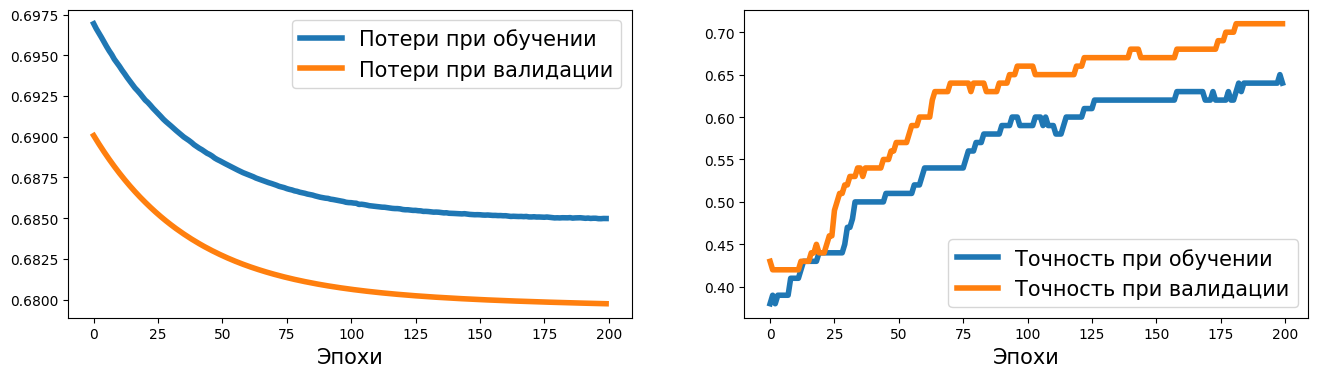

In [21]:
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Пoтepи при обучении', 'Потери при валидации'], fontsize=15)
ax.set_xlabel('Эпохи', size=15)

ax = fig.add_subplot(1, 2, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Точность при обучении', 'Точность при валидации'], fontsize=15)
ax.set_xlabel('Эпохи', size=15)

Очевидно, что простая модель без скрытого слоя может вывести только линейную границу решения, которая не может решить задачу XOR. Поэтому мы видим, что потери как для обучающих, так и для проверочных наборов данных очень высоки, а точность классификации весьма низкая. Чтобы получить нелинейную разделяющую границу, нужно добавить один или несколько скрытых слоев, связанных нелинейными функциями активации. Теорема универсальной аппроксимации утверждает, что нейронная сеть прямого распространения с одним скрытым слоем и достаточно большим количеством скрытых элементов может
относительно хорошо аппроксимировать произвольные непрерывные функции. Таким образом, один из подходов к более удовлетворительному решению задачи XOR состоит в том, чтобы добавить скрытый слой и сравнивать различное количество скрытых элементов, пока не будут достигнуты удовлетворительные результаты на проверочном наборе. Добавление дополнительных скрытых элементов соответствует увеличению ширины слоя. В качестве альтернативы можно также добавить больше скрытых слоев, что сделает модель более глубокой. Преимущество создания более глубокой, а не широкой сети заключается в том, что для достижения сравнимой емкости модели требуется меньше параметров.

Однако недостатком глубоких (по сравнению с широкими) моделей является то, что глубокие модели склонны к исчезновению и взрыву градиентов, а зто затрудняет их обучение. В качестве упражнения попробуйте добавить один, два, три и четыре скрытых слоя, каждый из которых содержит четыре скрытых элемента. В следующем примере мы рассмотрим нейросеть прямого распространения с двумя скрытыми слоями: 

In [22]:
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)
 
loss_fn = nn.BCELoss() # Вычисляет бинарную кросс-энтропию между предсказаниями (вероятности) и истинными метками (0 или 1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)

model

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
  (5): Sigmoid()
)

In [23]:
history = train(model, num_epochs, train_dl, x_valid, y_valid)

Text(0.5, 0, 'Epochs')

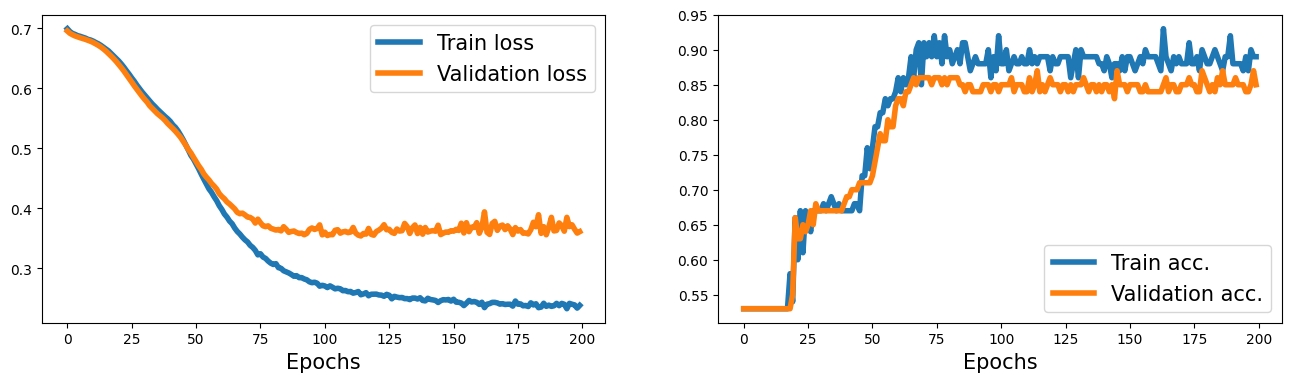

In [24]:
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

ax = fig.add_subplot(1, 2, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

Теперь мы видим, что модель может построить нелинейную разделяющую границу для имеющихся данных, и она достигает 100-процентной точности на обучающем наборе. Точность на проверочном наборе данных составляет 95%, что указывает на первые признаки переобучения. 

#### 13.5.4. Более гибкое построение моделей с помощью nn.Module 

В предьщущем примере мы использовали класс PyTorch sequential для создания полносвязной нейросети с несколькими уровнями. Это очень распространенный и удобный способ построения моделей. Однако, к сожалению, он не позволяет нам создавать более сложные модели с несколькими входными, выходными или промежуточными ветвями. Вот где может пригодиться nn.Module. Альтернативный способ построения сложных моделей - создание подкласса nn.Module.
При этом мы создаем новый класс, производный от nn.мoctule, и определяем метод _init_() в качестве конструктора, а метод forward() используется для определения прямого прохода. В функции-конструкторе _init_() мы определяем слои как атрибуты класса, чтобы к ним можно было получить доступ через атрибут ссылки self, а затем в методе forward() указываем, как эти слои должны использоваться при прямом проходе нейросети. Далее показан пример кода для определения нового класса, реализующего предыдущую модель: 

In [25]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        l1 = nn.Linear(2, 4)
        a1 = nn.ReLU()
        l2 = nn.Linear(4, 4)
        a2 = nn.ReLU()
        l3 = nn.Linear(4, 1)
        a3 = nn.Sigmoid()
        l = [l1, a1, l2, a2, l3, a3]
        self.module_list = nn.ModuleList(l)

    def forward(self, x):
        for f in self.module_list:
            x = f(x)
        return x
    
    def predict(self, x):
        x = torch.tensor(x, dtype=torch.float32)
        pred = self.forward(x)[:, 0]
        return (pred>=0.5).float()
            
model = MyModule()
model


MyModule(
  (module_list): ModuleList(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Обратите внимание, что мы поместили все слои в объект nn.ModuleList, который представляет собой просто объект list, состоящий из элементов nn.Module. Это делает код более читаемым и понятным. Определив экземпляр нового класса, мы можем обучить его, как делали это ранее: 

In [26]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)
history = train(model, num_epochs, train_dl, x_valid, y_valid)

Далее, помимо истории обучения, мы воспользуемся библиотекой mlxtend для визуализации проверочных данных и разделяющей границы. 

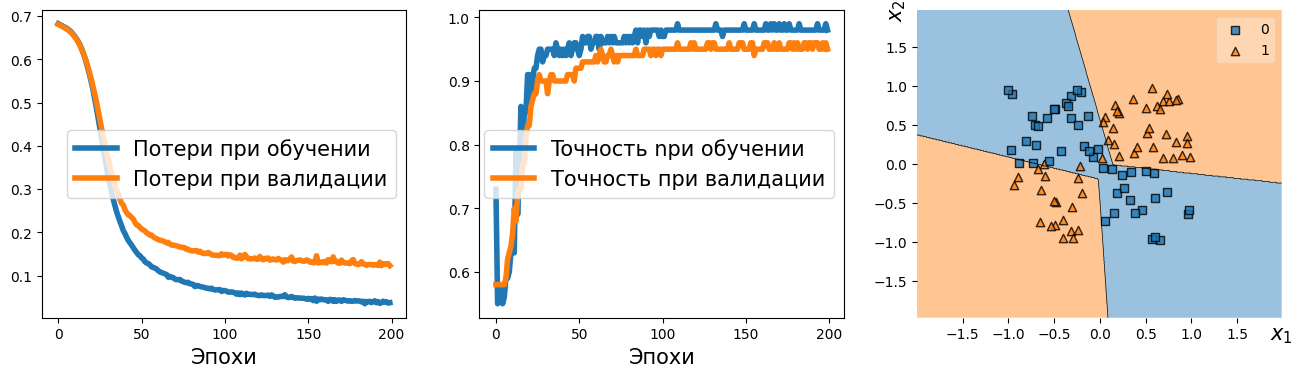

In [ ]:
from mlxtend.plotting import plot_decision_regions

fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Пoтepи при обучении', 'Потери при валидации'], fontsize=15)
ax.set_xlabel('Эпохи', size=15)

ax = fig.add_subplot(1, 3, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Toчнocть nри обучении', 'Точность при валидации'], fontsize=15)
ax.set_xlabel('Эпохи', size=15)

ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_valid.numpy(), 
                      y=y_valid.numpy().astype(np.int64),
                      clf=model)
ax.set_xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
ax.set_ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)
plt.show()

#### 13.5.5. Создание в PyTorch пользовательских слоев

В тех случаях, когда нужно включить в модель новый слой, который еще не поддерживает PyTorch, мы можем определить новый класс, производный от класса nn.Module. Это особенно полезно при разработке нового слоя или настройке существующего. Рассмотрим простой пример создания пользовательского слоя. Допустим, нам нужно определить новый линейный слой, который вычисляет w(x + Е) + b, где Е представляет собой случайную величину (шумовую переменную). Чтобы реализовать это вычисление, определим новый класс как подкласс nn.мodule. Для этого нового класса мы должны определить как метод конструктора _init_(), так и метод forward(). В конструкторе мы определяем переменные и другие необходимые тензоры для нашего пользовательского слоя. Мы можем создавать переменные и инициализировать их в конструкторе, если конструктору передается input_size. В качестве альтернативы мы можем отложить инициализацию переменной (например, если мы заранее не знаем точную форму ввода) и делегировать ее другому методу для последующего создания переменной.
Для более конкретного примера определим новый слой с именем NoisyLinear, который реализует вычисление приведенного ранее выражения w(x + Е) + b: 

In [28]:
class NoisyLinear(nn.Module):
    def __init__(self, input_size, output_size, noise_stddev=0.1):
        super().__init__()
        w = torch.Tensor(input_size, output_size)
        self.w = nn.Parameter(w)  # nn.Pararneter это Tensor это параметр модуля. 
        nn.init.xavier_uniform_(self.w)
        b = torch.Tensor(output_size).fill_(0)
        self.b = nn.Parameter(b)
        self.noise_stddev = noise_stddev

    def forward(self, x, training=False):
        if training:
            noise = torch.normal(0.0, self.noise_stddev, x.shape)
            x_new = torch.add(x, noise)
        else:
            x_new = x
        return torch.add(torch.mm(x_new, self.w), self.b)   

В конструкторе мы добавили аргумент noise_stddev, чтобы задать стандартное отклонение для распределения Е, которое извлекается из распределения Гаусса. Кроме того, обратите внимание, что в методе forward() был задействован дополнительный аргумент training=False. Мы сделали это, чтобы указать, используется ли слой во время обучения или только для прогнозирования (иногда это также называют логическим выводом).
Также существуют определенные методы, которые по-разному ведут себя в режимах обучения и прогнозирования. В следующих главах вы встретите пример такого метода - Dropout. В приведенном фрагменте кода мы также указали, что случайный вектор Е должен генерироваться и добавляться ко входным данным только во время обучения и не использоваться для вывода или оценки. Прежде чем мы сделаем следующий шаг и включим наш пользовательский слой NoisyLinear в состав модели, давайте проверим его на простом примере.
1. В следующем коде мы определим новый экземпляр этого слоя и применим его ко входному тензору. Затем мы трижды вызовем слой для одного и того же входного
тензора: 

In [31]:
torch.manual_seed(1)

noisy_layer = NoisyLinear(4, 2)
 
x = torch.zeros((1, 4))
print(noisy_layer(x, training=True))

print(noisy_layer(x, training=True))
 
print(noisy_layer(x, training=False))
 

tensor([[ 0.1154, -0.0598]], grad_fn=<AddBackward0>)
tensor([[ 0.0432, -0.0375]], grad_fn=<AddBackward0>)
tensor([[0., 0.]], grad_fn=<AddBackward0>)


Обратите внимание, что выходные данные для первых двух вызовов различаются, потому что слой NoisyLinear добавил ко входному тензору случайный шум. Третий
вызов выводит [0, 0], т. к. мы не добавляли шум, указав training=False.
2. Теперь создадим новую модель, аналогичную предыдущей, для решения задачи классификации XOR. Как и прежде, мы будем использовать класс nn.Moclule для
построения модели, но на этот раз включим в модель слой NoisyLinear в качестве первого скрытого слоя многослойного персептрона: 

In [32]:
class MyNoisyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = NoisyLinear(2, 4, 0.07)
        self.a1 = nn.ReLU()
        self.l2 = nn.Linear(4, 4)
        self.a2 = nn.ReLU()
        self.l3 = nn.Linear(4, 1)
        self.a3 = nn.Sigmoid()
        
    def forward(self, x, training=False):
        x = self.l1(x, training)
        x = self.a1(x)
        x = self.l2(x)
        x = self.a2(x)
        x = self.l3(x)
        x = self.a3(x)
        return x
    
    def predict(self, x):
        x = torch.tensor(x, dtype=torch.float32)
        pred = self.forward(x)[:, 0]
        return (pred>=0.5).float()

torch.manual_seed(1)
model = MyNoisyModule()
model

MyNoisyModule(
  (l1): NoisyLinear()
  (a1): ReLU()
  (l2): Linear(in_features=4, out_features=4, bias=True)
  (a2): ReLU()
  (l3): Linear(in_features=4, out_features=1, bias=True)
  (a3): Sigmoid()
)

3. Обучим модель, как и раньше. В рассматриваемом случае, чтобы вычислить прогноз для обучающего пакета, мы используем pred = model(x_batch, True) [:, 0] вместо pred = model(x_batch) [:, О]:

In [33]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)
    
torch.manual_seed(1)

loss_hist_train = [0] * num_epochs
accuracy_hist_train = [0] * num_epochs
loss_hist_valid = [0] * num_epochs
accuracy_hist_valid = [0] * num_epochs
for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch, True)[:, 0]
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_hist_train[epoch] += loss.item()
        is_correct = ((pred>=0.5).float() == y_batch).float()
        accuracy_hist_train[epoch] += is_correct.mean()

    loss_hist_train[epoch] /= n_train/batch_size
    accuracy_hist_train[epoch] /= n_train/batch_size

    pred = model(x_valid)[:, 0]
    loss = loss_fn(pred, y_valid)
    loss_hist_valid[epoch] = loss.item()
    is_correct = ((pred>=0.5).float() == y_valid).float()
    accuracy_hist_valid[epoch] += is_correct.mean()

4. Обучив модель, снова построим графики потери и точности и разделяющую границу:

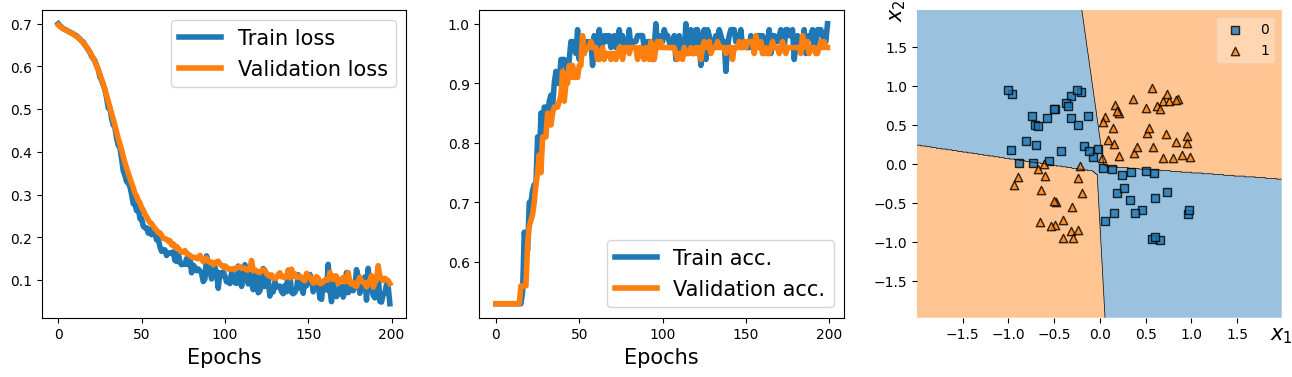

In [34]:
from mlxtend.plotting import plot_decision_regions


fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(loss_hist_train, lw=4)
plt.plot(loss_hist_valid, lw=4)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

ax = fig.add_subplot(1, 3, 2)
plt.plot(accuracy_hist_train, lw=4)
plt.plot(accuracy_hist_valid, lw=4)
plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_valid.numpy(), 
                      y=y_valid.numpy().astype(np.int64),
                      clf=model)
ax.set_xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
ax.set_ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)
plt.show()

Этот пример помог нам научиться определять новый пользовательский слой, являющийся подклассом nn.мodule, и использовать его так же, как любой другой стандартный слой torch.nn. Хотя в этом конкретном примере NoisyLinear не помог улучшить производительность модели, наша цель в основном заключалась в том, чтобы научиться создавать пользовательский слой с нуля. В общем случае создание нового слоя может быть полезно, например, если вы разрабатываете новый алгоритм, зависящий от нового слоя, помимо существующих. 